<a href="https://colab.research.google.com/github/ArshadNazir1/flyrank-ml-internship-starter/blob/main/work/notebooks/capstone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Capstone — mirrors your deployed research paper

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question

*The research question and the decision it supports.*

**Lane:** Lane 2 — Refresh / Content Opportunity Scoring.

**Research question:** Which content pages should be reviewed first, based on their search performance, freshness, and engagement data?

**Decision and action:** This supports a content editor or SEO team deciding which pages to look at first instead of checking every page manually. After reviewing a flagged page, the team decides whether to refresh, expand, protect, prune, or simply monitor it. The output only supports that decision — it never makes it.

**Unit of analysis:** one anonymized content page, from `data/raw/content_refresh_anonymized.csv` — the same starter dataset used in every notebook below.

**Expected output:** a ranked queue where each page has a priority band, a recommended action, a reason code, and a model score (built in Section 6).

**Cost of a wrong call:** a false positive costs a reviewer's time on a page that didn't need it — recoverable. A false negative leaves a page that does need attention unreviewed, since nothing flagged it — the more expensive mistake, and the one the recall number in Section 4 speaks to.

**Why data/ML helps:** a single fixed rule can only combine one or two signals at once (Section 3's baseline uses staleness and visibility). Whether a page is underperforming depends on several signals together — position, freshness, content type, intent, competition — so a model that can weigh many features at once should do better than one hand-written rule, *if* it actually beats that rule on the same data. Section 4 checks whether it does.

In [4]:
import pandas as pd
import numpy as np

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

df = pd.read_csv(
    "https://raw.githubusercontent.com/ArshadNazir1/flyrank-ml-internship-starter/main/data/raw/content_refresh_anonymized.csv"
)

print("Rows:", len(df))
print("Columns:", len(df.columns))
print("Distinct clients:", df["client_id"].nunique())

Rows: 30000
Columns: 44
Distinct clients: 32


## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

**Source:** the bundled starter release, `data/raw/content_refresh_anonymized.csv` — 30,000 anonymized content pages, one row per page, a single ~90-day snapshot (not a time series). `client_id` and `content_id` are anonymized hashes; no client names, URLs, or raw queries appear anywhere in this notebook or its outputs.

**Kept as features:** `avg_position`, `position_tier`, `impressions_90d`, `impressions_last_30d`, `impressions_prev_30d`, `days_since_last_update`, `content_age_days`, `days_with_impressions`, `word_count`, `char_count`, `search_volume`, `competition`, `competition_level`, `cpc`, `content_type`, `main_intent`, `provider_used`, `model_used` — plus a `has_*` missingness flag for each numeric field that has gaps.

**Deliberately excluded from modeling** (kept only as diagnostics or to build the target, never as model inputs): `ctr`, `clicks`, `sessions`, `pageviews`, `engagement_rate`, `scroll_rate`, `ai_traffic_pct`, `trend_direction`, `trend_pct`, `is_declining_label`. These are outcome-adjacent — using them as features would leak the answer into the model, since the target below is built from `ctr`.

**Identifiers:** `client_id` is used only for grouping the validation split (Section 3), never as a feature. `content_id` is a row identifier only.

**Rows without ranking data:** 1,205 of the 30,000 rows have no `avg_position` (page never ranked). They're excluded from modeling since the target is only defined for ranked pages — verified below.

In [5]:
df["has_position"] = df["avg_position"] > 0

print("Rows with a ranking position:", df["has_position"].sum())
print("Rows without a ranking position (excluded from modeling):", (~df["has_position"]).sum())

excluded_from_features = [
    "ctr", "clicks", "sessions", "pageviews", "engagement_rate", "scroll_rate",
    "ai_traffic_pct", "trend_direction", "trend_pct", "is_declining_label",
]
print("\nColumns present but excluded from model features:")
print([c for c in excluded_from_features if c in df.columns])

Rows with a ranking position: 28795
Rows without a ranking position (excluded from modeling): 1205

Columns present but excluded from model features:
['ctr', 'engagement_rate', 'scroll_rate', 'ai_traffic_pct', 'trend_direction', 'trend_pct']


## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

**ML framing:** supervised binary classification, used to power a ranking/prioritization queue (Section 6). Chosen over an unsupervised approach because historical search-performance data gives labeled examples to learn from directly.

**Target (proxy):** `ctr_underperforming` — a page's CTR is below the median CTR for its own `position_tier`. There's no ground-truth "needs refresh" label in this dataset, so this is a proxy built from observed CTR relative to peers at the same position, not a manually invented rule.

**Baseline (the fair comparison):** a position-vs-tier-median rule — flag a page if its `avg_position` is worse than the median position for its tier. The Week-4 rule (staleness + visibility + CTR gap) is *not* used here as the ML baseline, because it uses CTR directly, and CTR is what the target is built from — comparing against it would be comparing the model to a rule that can see the answer.

**Method:** Logistic Regression, `class_weight="balanced"` (the positive rate is 45.4%, close to balanced already), inside a `ColumnTransformer` (median-impute + scale numeric, one-hot encode categorical).

**Split design:** `StratifiedGroupKFold`, 5 folds, grouped by `client_id`. This keeps every page from the same client on one side of each fold, so the model is never tested on a client it partly trained on. A time-aware split wasn't possible — the data is a single snapshot, not a time series.

**Leakage check:** every outcome-adjacent column listed in Section 2 is confirmed absent from the feature set below — the same hunt run in Week 3, repeated here on the final feature list.

In [6]:
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

median_ctr_per_tier = df[df["has_position"]].groupby("position_tier")["ctr"].median()
df["expected_ctr"] = df["position_tier"].map(median_ctr_per_tier)
df["ctr_underperforming"] = df["has_position"] & (df["ctr"] < df["expected_ctr"])

model_df = df[df["has_position"]].copy()
model_df["provider_used"] = model_df["provider_used"].fillna("unknown")
for col in ["word_count", "char_count", "search_volume", "competition", "cpc"]:
    model_df[f"has_{col}"] = model_df[col].notna().astype(int)

y = model_df["ctr_underperforming"].astype(int)
groups = model_df["client_id"]

feature_cols_num = [
    "search_volume", "competition", "cpc", "word_count", "char_count",
    "avg_position", "impressions_90d", "impressions_last_30d", "impressions_prev_30d",
    "days_since_last_update", "content_age_days", "days_with_impressions",
    "has_word_count", "has_char_count", "has_search_volume", "has_competition", "has_cpc",
]
feature_cols_cat = [
    "content_type", "main_intent", "competition_level",
    "position_tier", "provider_used", "model_used",
]
X = model_df[feature_cols_num + feature_cols_cat]

# Leakage check on the final feature set
leaked = set(excluded_from_features).intersection(set(feature_cols_num + feature_cols_cat))
print("Leakage columns found in final feature set:", leaked if leaked else "none")
print("client_id / content_id used as features:", any(c in feature_cols_num + feature_cols_cat for c in ["client_id", "content_id"]))

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])
preprocess = ColumnTransformer([
    ("num", numeric_pipeline, feature_cols_num),
    ("cat", OneHotEncoder(handle_unknown="ignore"), feature_cols_cat),
])

def make_model():
    return Pipeline([
        ("prep", preprocess),
        ("lr", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_SEED)),
    ])

sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)
print("\nRows modeled:", len(model_df), "| Clients:", groups.nunique(), "| Positive rate:", round(y.mean(), 4))
for fold, (train_idx, test_idx) in enumerate(sgkf.split(X, y, groups)):
    print(f"Fold {fold + 1}: Train={len(train_idx)}, Test={len(test_idx)}")

Leakage columns found in final feature set: none
client_id / content_id used as features: False

Rows modeled: 28795 | Clients: 31 | Positive rate: 0.4542
Fold 1: Train=23906, Test=4889
Fold 2: Train=23560, Test=5235
Fold 3: Train=16553, Test=12242
Fold 4: Train=22860, Test=5935
Fold 5: Train=28301, Test=494


## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

**Base rate:** 45.4% of ranked pages are `ctr_underperforming` — worth stating up front, since a model needs to clear this before any accuracy number means much.

**Model vs baseline, same data, same client-grouped split:** Logistic Regression beats the position baseline on every metric except recall being lower than its own precision (it misses more real underperformers than it wrongly flags fine pages).

**Why the split matters:** re-running the same model under a plain random row split instead of the client-grouped split (Week 6's check) inflates every number — because pages from the same client leak similar patterns across train and test. The grouped result below is the honest one; the random one is shown only to demonstrate the gap.

In [7]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.model_selection import StratifiedKFold

# --- Fair ML baseline: position vs tier-median position (does NOT use CTR) ---
tier_median_position = model_df.groupby("position_tier")["avg_position"].transform("median")
baseline_pred = (model_df["avg_position"] > tier_median_position).astype(int)

def evaluate(name, y_true, pred, proba=None):
    return {
        "Model": name,
        "Accuracy": round(accuracy_score(y_true, pred), 3),
        "Precision": round(precision_score(y_true, pred), 3),
        "Recall": round(recall_score(y_true, pred), 3),
        "F1": round(f1_score(y_true, pred), 3),
        "ROC_AUC": round(roc_auc_score(y_true, proba), 3) if proba is not None else None,
    }

# --- Logistic Regression, client-grouped CV (the honest result) ---
group_pred = np.zeros(len(X), dtype=int)
group_proba = np.zeros(len(X))
for train_idx, test_idx in sgkf.split(X, y, groups):
    m = make_model()
    m.fit(X.iloc[train_idx], y.iloc[train_idx])
    proba = m.predict_proba(X.iloc[test_idx])[:, 1]
    group_proba[test_idx] = proba
    group_pred[test_idx] = (proba >= 0.5).astype(int)

# --- Same model, random row-level split (shown only to demonstrate why grouping matters) ---
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)
row_pred = np.zeros(len(X), dtype=int)
row_proba = np.zeros(len(X))
for train_idx, test_idx in skf.split(X, y):
    m = make_model()
    m.fit(X.iloc[train_idx], y.iloc[train_idx])
    proba = m.predict_proba(X.iloc[test_idx])[:, 1]
    row_proba[test_idx] = proba
    row_pred[test_idx] = (proba >= 0.5).astype(int)

comparison = pd.DataFrame([
    evaluate("Position Baseline (client-grouped)", y, baseline_pred),
    evaluate("Logistic Regression — random row split", y, row_pred, row_proba),
    evaluate("Logistic Regression — client-grouped split (honest)", y, group_pred, group_proba),
])
print("Base rate (positive class):", round(y.mean(), 4))
comparison

Base rate (positive class): 0.4542


,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Position Baseline (client-grouped),0.547,0.502,0.544,0.522,NaN
1,Logistic Regression — random row split,0.752,0.736,0.709,0.722,0.834
2,Logistic Regression — client-grouped split (ho...,0.731,0.752,0.610,0.674,0.796


## 5. Limitations

*What this work cannot claim.*

- This is a single ~90-day snapshot, not a time series — I can't say whether a flagged page actually improves after review.
- The client-grouped validation covers 31 clients. A client very different from this pool is untested.
- Recall is lower than precision in Section 4's client-grouped result, so some real underperformers are still missed — a low `model_score` does not mean a page is fine.
- The target, `ctr_underperforming`, is built from this dataset's own position-tier medians, not an outside benchmark — it moves if the dataset changes.
- `model_score` uses `class_weight="balanced"`, so it's a ranking signal, not a calibrated probability.
- The freshness pattern in Section 6 (older pages score higher) is an observed association in one snapshot — it does not prove staleness causes underperformance, or that refreshing a page fixes it. It could just as easily be that already-struggling pages get updated less often.
- This model measures a directional, decision-support relationship in the evaluated dataset. It does not prove causation, and it does not guarantee the same performance on future or unseen data.

In [8]:
print("Client-grouped validation summary:")
print("  clients validated on:", groups.nunique())
print("  precision:", round(precision_score(y, group_pred), 3))
print("  recall:", round(recall_score(y, group_pred), 3), "(lower than precision — some underperformers are missed)")

Client-grouped validation summary:
  clients validated on: 31
  precision: 0.752
  recall: 0.61 (lower than precision — some underperformers are missed)


## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

**Intended use:** a review-prioritization tool for a content or SEO team — a ranked list of pages to look at first, with a reason for each. Built for a human doing manual review, not for automated publishing. It only decides what to look at first; it never decides what to change, and it never edits or publishes anything on its own.

**Thresholds:** taken from the actual score distribution (top decile / top quartile of `model_score`, top quartile of `impressions_90d`), not chosen arbitrarily.

**What a human should check before acting:** confirm the reason code matches reality (the page really hasn't been updated, not just that the field looks stale in this export); look at the page's actual context, since a high score with low impressions may mean the page never had real traffic; consider seasonality, since a 90-day window can catch a page mid-dip for unrelated reasons.

**What should never be automated from this output:** no automatic publishing, editing, or removing content; no automatic title/snippet changes from a CTR-gap flag alone; no automatic deprioritizing or pruning — `Monitor` means no strong signal was found, not that a page is safe to remove; no using `model_score` to judge a person's or team's performance; no treating a low score as proof a page is fine, given recall in Section 4 is well below 1.0.

In [9]:
# model_score = the out-of-fold client-grouped probabilities from Section 4 — never a page's own
# training fold, matching the Week-7 approach.
model_df["model_score"] = group_proba

model_df["is_stale"] = model_df["days_since_last_update"] >= 180

MODEL_HIGH_THRESHOLD = model_df["model_score"].quantile(0.90)
MODEL_REVIEW_THRESHOLD = model_df["model_score"].quantile(0.75)
IMPRESSIONS_HIGH_THRESHOLD = model_df["impressions_90d"].quantile(0.75)

model_df["high_model_score"] = model_df["model_score"] >= MODEL_HIGH_THRESHOLD
model_df["model_review_band"] = model_df["model_score"] >= MODEL_REVIEW_THRESHOLD
model_df["high_visibility"] = model_df["impressions_90d"] >= IMPRESSIONS_HIGH_THRESHOLD

def assign_action_and_reason(row):
    if row["high_model_score"] and row["is_stale"]:
        return pd.Series({"recommended_action": "Refresh Content - Human Review",
                           "reason_code": "RC_HIGH_MODEL_AND_STALE",
                           "reason_explanation": "Top-decile model score and 180+ days since last update.",
                           "priority_band": 1})
    elif row["high_model_score"]:
        return pd.Series({"recommended_action": "Review Content and Search Alignment",
                           "reason_code": "RC_HIGH_MODEL_RISK",
                           "reason_explanation": "Top-decile model score, but page was updated recently.",
                           "priority_band": 2})
    elif row["high_visibility"] and row["ctr_underperforming"]:
        return pd.Series({"recommended_action": "Review Search Result Presentation",
                           "reason_code": "RC_HIGH_VISIBILITY_CTR_GAP",
                           "reason_explanation": "High impressions but CTR below the tier median.",
                           "priority_band": 3})
    elif row["model_review_band"]:
        return pd.Series({"recommended_action": "Review Content Candidate",
                           "reason_code": "RC_MODEL_REVIEW",
                           "reason_explanation": "Model score in the general review range, no specific cause identified.",
                           "priority_band": 4})
    else:
        return pd.Series({"recommended_action": "Monitor",
                           "reason_code": "RC_MONITOR",
                           "reason_explanation": "No signal strong enough to justify immediate action.",
                           "priority_band": 5})

action_fields = model_df.apply(assign_action_and_reason, axis=1)
playbook_df = pd.concat([model_df, action_fields], axis=1)

ranked_queue = (
    playbook_df
    .sort_values(by=["priority_band", "model_score", "impressions_90d"], ascending=[True, False, False])
    .reset_index(drop=True)
)
ranked_queue["queue_rank"] = np.arange(len(ranked_queue)) + 1

queue_columns = [
    "queue_rank", "content_id", "client_id", "priority_band", "recommended_action",
    "reason_code", "reason_explanation", "model_score", "is_stale",
    "days_since_last_update", "ctr_underperforming", "impressions_90d",
]
ranked_queue = ranked_queue[queue_columns]

print("Top 10 ranked actions:")
display(ranked_queue.head(10))

print("\nAction counts:")
display(ranked_queue["recommended_action"].value_counts().rename_axis("recommended_action").reset_index(name="count"))

Top 10 ranked actions:


,queue_rank,content_id,client_id,priority_band,recommended_action,reason_code,reason_explanation,model_score,is_stale,days_since_last_update,ctr_underperforming,impressions_90d
0,1,content_8d56efff1e71,client_4ec9599fc2,1,Refresh Content - Human Review,RC_HIGH_MODEL_AND_STALE,Top-decile model score and 180+ days since las...,0.989912,True,372,True,1
1,2,content_f6fdf87348f6,client_4ec9599fc2,1,Refresh Content - Human Review,RC_HIGH_MODEL_AND_STALE,Top-decile model score and 180+ days since las...,0.988774,True,373,True,2
2,3,content_1b4ec72dafd4,client_4ec9599fc2,1,Refresh Content - Human Review,RC_HIGH_MODEL_AND_STALE,Top-decile model score and 180+ days since las...,0.987243,True,372,True,2
3,4,content_dd413158df3c,client_19581e27de,1,Refresh Content - Human Review,RC_HIGH_MODEL_AND_STALE,Top-decile model score and 180+ days since las...,0.987201,True,305,True,13
4,5,content_afd26a07382d,client_19581e27de,1,Refresh Content - Human Review,RC_HIGH_MODEL_AND_STALE,Top-decile model score and 180+ days since las...,0.985350,True,305,True,15
5,6,content_06e19c6486b0,client_4ec9599fc2,1,Refresh Content - Human Review,RC_HIGH_MODEL_AND_STALE,Top-decile model score and 180+ days since las...,0.978485,True,334,True,10
6,7,content_da54cb4484f1,client_d4735e3a26,1,Refresh Content - Human Review,RC_HIGH_MODEL_AND_STALE,Top-decile model score and 180+ days since las...,0.975508,True,211,True,1
7,8,content_d28d84af56c2,client_d4735e3a26,1,Refresh Content - Human Review,RC_HIGH_MODEL_AND_STALE,Top-decile model score and 180+ days since las...,0.974477,True,211,False,3
8,9,content_573248f65db2,client_d4735e3a26,1,Refresh Content - Human Review,RC_HIGH_MODEL_AND_STALE,Top-decile model score and 180+ days since las...,0.973680,True,211,True,1
9,10,content_026a1e2a82fd,client_19581e27de,1,Refresh Content - Human Review,RC_HIGH_MODEL_AND_STALE,Top-decile model score and 180+ days since las...,0.973498,True,305,True,13



Action counts:


,recommended_action,count
0,Monitor,20032
1,Review Content Candidate,4303
2,Review Content and Search Alignment,2798
3,Review Search Result Presentation,1580
4,Refresh Content - Human Review,82


## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

Two figures and four tables — the ones the deployed paper reuses directly:

- `work/figures/capstone_action_counts.png` — how many pages land in each recommended action.
- `work/figures/capstone_freshness_insight.png` — mean model score by freshness tier (the observational decay pattern noted in Section 5).
- `work/outputs/capstone_ranked_action_queue.csv` — the full ranked queue.
- `work/outputs/capstone_action_summary.csv` — action counts.
- `work/outputs/capstone_model_comparison.csv` — the Section 4 comparison table.
- `work/outputs/capstone_metrics.json` — validated metrics + thresholds, for the paper's results section.

Wrote capstone_ranked_action_queue.csv, capstone_action_summary.csv,
      capstone_model_comparison.csv, capstone_metrics.json


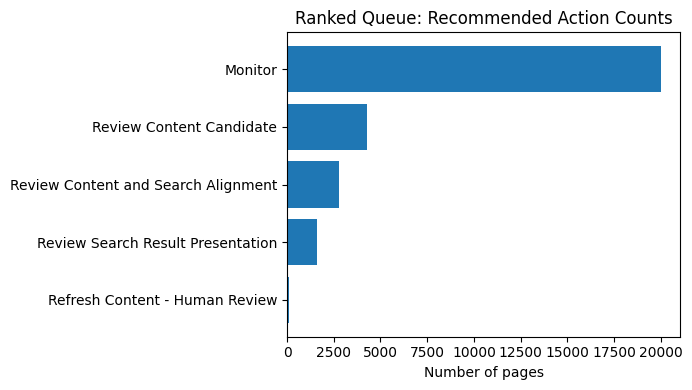

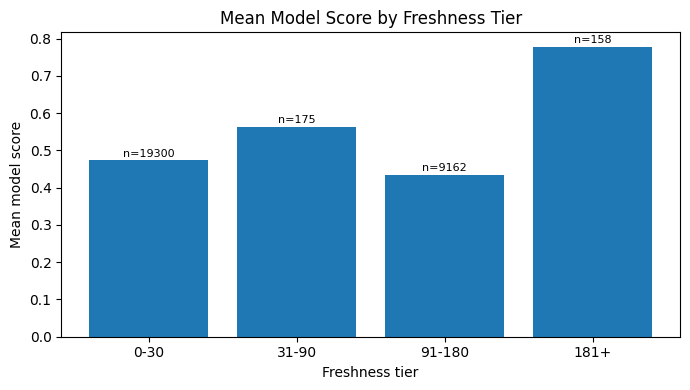

In [10]:
import json
import os
import matplotlib.pyplot as plt

os.makedirs("work/outputs", exist_ok=True)
os.makedirs("work/figures", exist_ok=True)

# --- Tables ---
ranked_queue.to_csv("work/outputs/capstone_ranked_action_queue.csv", index=False)

action_summary = (
    ranked_queue["recommended_action"]
    .value_counts()
    .rename_axis("recommended_action")
    .reset_index(name="count")
)
action_summary.to_csv("work/outputs/capstone_action_summary.csv", index=False)

comparison.to_csv("work/outputs/capstone_model_comparison.csv", index=False)

cv_metrics = {
    "n_rows": int(len(model_df)),
    "n_clients": int(groups.nunique()),
    "positive_rate": round(float(y.mean()), 4),
    "accuracy": round(accuracy_score(y, group_pred), 4),
    "precision": round(precision_score(y, group_pred), 4),
    "recall": round(recall_score(y, group_pred), 4),
    "f1": round(f1_score(y, group_pred), 4),
    "roc_auc": round(roc_auc_score(y, group_proba), 4),
}

metrics_export = {
    "model": "logistic_regression_ctr_underperforming",
    "validation": "client_grouped_stratified_5fold",
    "cv_metrics": cv_metrics,
    "thresholds": {
        "model_score_top_decile": round(float(MODEL_HIGH_THRESHOLD), 4),
        "model_score_top_quartile": round(float(MODEL_REVIEW_THRESHOLD), 4),
        "impressions_90d_top_quartile": round(float(IMPRESSIONS_HIGH_THRESHOLD), 1),
        "stale_days_since_update": 180,
    },
    "intended_use": "Human-reviewed content prioritization and decision-support",
    "causal_claims_supported": False,
}
with open("work/outputs/capstone_metrics.json", "w") as f:
    json.dump(metrics_export, f, indent=2)

print("Wrote capstone_ranked_action_queue.csv, capstone_action_summary.csv,")
print("      capstone_model_comparison.csv, capstone_metrics.json")

# --- Figure 1: action counts ---
fig1, ax1 = plt.subplots(figsize=(7, 4))
order = action_summary.sort_values("count", ascending=True)
ax1.barh(order["recommended_action"], order["count"])
ax1.set_xlabel("Number of pages")
ax1.set_title("Ranked Queue: Recommended Action Counts")
fig1.tight_layout()
fig1.savefig("work/figures/capstone_action_counts.png", dpi=150, bbox_inches="tight")
plt.show()

# --- Figure 2: freshness insight ---
freshness_order = ["0-30", "31-90", "91-180", "181+"]
freshness_means = playbook_df.groupby("freshness_tier")["model_score"].mean().reindex(freshness_order)
freshness_n = playbook_df.groupby("freshness_tier")["model_score"].size().reindex(freshness_order)

fig2, ax2 = plt.subplots(figsize=(7, 4))
bars = ax2.bar(freshness_means.index, freshness_means.values)
for bar, n in zip(bars, freshness_n.values):
    if pd.notna(n):
        ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01, f"n={int(n)}", ha="center", fontsize=8)
ax2.set_ylabel("Mean model score")
ax2.set_xlabel("Freshness tier")
ax2.set_title("Mean Model Score by Freshness Tier")
fig2.tight_layout()
fig2.savefig("work/figures/capstone_freshness_insight.png", dpi=150, bbox_inches="tight")
plt.show()

## Self-check

Before you submit, confirm each line honestly:

- [x] Every section above is filled — markdown thinking AND the code that backs it
- [x] The notebook runs top to bottom with no errors (Runtime → Run all)
- [x] No client names, URLs, or private queries anywhere
- [x] My claims use careful words: observed, measured, directional, decision-support
- [x] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.